In [3]:
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gymnasium', '-q'])
    import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Using Taxi-v4 to avoid deprecation warnings or exceptions
env = gym.make('Taxi-v4')
n_s = env.observation_space.n
n_a = env.action_space.n
print(f"Taxi-v4 Environment Initialized: {n_s} states, {n_a} actions.")


Taxi-v4 Environment Initialized: 500 states, 6 actions.


--- EXERCISE 1 RUNNING ---


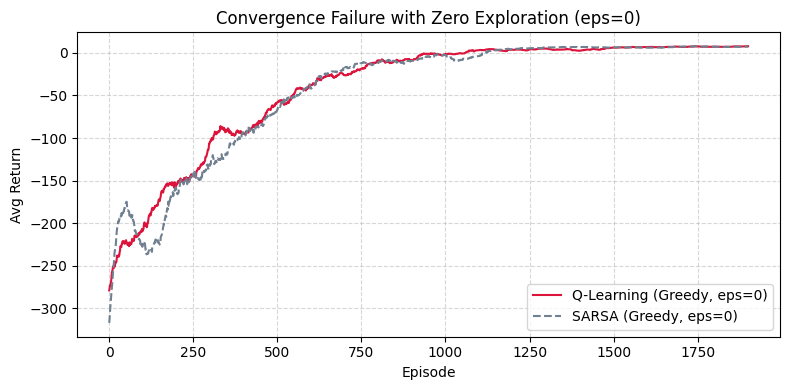

Conclusion: Neither algorithm converges optimally without exploration; they immediately lock into suboptimal local maxima loops.


In [4]:
def run_greedy_experiment(env, algorithm='q_learning', n_episodes=2000, alpha=0.1, gamma=0.99):
    Q = np.zeros((n_s, n_a))
    returns_per_ep = []

    for ep in range(n_episodes):
        s, _ = env.reset()
        ep_return = 0.0
        done = False

        # Initial action for SARSA
        if algorithm == 'sarsa':
            a = np.argmax(Q[s])

        while not done:
            if algorithm == 'q_learning':
                a = np.argmax(Q[s])
                ns, r, term, trunc, _ = env.step(a)
                done = term or trunc

                # Off-policy maximum target update
                Q[s, a] += alpha * (r + gamma * np.max(Q[ns]) * (not done) - Q[s, a])
                s = ns

            elif algorithm == 'sarsa':
                ns, r, term, trunc, _ = env.step(a)
                done = term or trunc
                na = np.argmax(Q[ns])

                # On-policy targeted update
                Q[s, a] += alpha * (r + gamma * Q[ns, na] * (not done) - Q[s, a])
                s, a = ns, na

            ep_return += r
        returns_per_ep.append(ep_return)

    return returns_per_ep

print("--- EXERCISE 1 RUNNING ---")
greedy_q_returns = run_greedy_experiment(env, algorithm='q_learning')
greedy_sarsa_returns = run_greedy_experiment(env, algorithm='sarsa')

window = 100
rolling_greedy_q = np.convolve(greedy_q_returns, np.ones(window)/window, mode='valid')
rolling_greedy_sarsa = np.convolve(greedy_sarsa_returns, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8, 4))
plt.plot(rolling_greedy_q, color='crimson', label='Q-Learning (Greedy, eps=0)')
# Fixed: Changed 'slate grey' to 'slategray' to prevent Matplotlib ValueError
plt.plot(rolling_greedy_sarsa, color='slategray', label='SARSA (Greedy, eps=0)', linestyle='--')
plt.xlabel('Episode')
plt.ylabel('Avg Return')
plt.title('Convergence Failure with Zero Exploration (eps=0)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Conclusion: Neither algorithm converges optimally without exploration; they immediately lock into suboptimal local maxima loops.")


--- EXERCISE 2 RUNNING ---


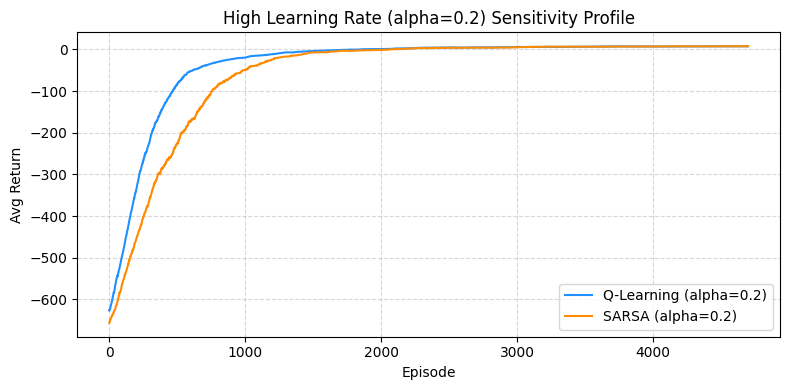

In [5]:
def run_control_with_alpha(env, algorithm='q_learning', alpha=0.2, n_episodes=5000, gamma=0.99, eps_start=1.0, eps_end=0.01, eps_decay=0.999):
    Q = np.zeros((n_s, n_a))
    eps = eps_start
    returns_per_ep = []

    for ep in range(n_episodes):
        s, _ = env.reset()
        ep_return = 0.0
        done = False

        def eps_greedy(state):
            if np.random.rand() < eps:
                return env.action_space.sample()
            return np.argmax(Q[state])

        if algorithm == 'sarsa':
            a = eps_greedy(s)

        while not done:
            if algorithm == 'q_learning':
                a = eps_greedy(s)
                ns, r, term, trunc, _ = env.step(a)
                done = term or trunc
                Q[s, a] += alpha * (r + gamma * np.max(Q[ns]) * (not done) - Q[s, a])
                s = ns
            elif algorithm == 'sarsa':
                ns, r, term, trunc, _ = env.step(a)
                done = term or trunc
                na = eps_greedy(ns)
                Q[s, a] += alpha * (r + gamma * Q[ns, na] * (not done) - Q[s, a])
                s, a = ns, na

            ep_return += r

        eps = max(eps_end, eps * eps_decay)
        returns_per_ep.append(ep_return)

    return returns_per_ep

print("--- EXERCISE 2 RUNNING ---")
high_alpha_q = run_control_with_alpha(env, algorithm='q_learning', alpha=0.2)
high_alpha_sarsa = run_control_with_alpha(env, algorithm='sarsa', alpha=0.2)

window = 300
rolling_ha_q = np.convolve(high_alpha_q, np.ones(window)/window, mode='valid')
rolling_ha_sarsa = np.convolve(high_alpha_sarsa, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8, 4))
plt.plot(rolling_ha_q, color='dodgerblue', label='Q-Learning (alpha=0.2)')
plt.plot(rolling_ha_sarsa, color='darkorange', label='SARSA (alpha=0.2)')
plt.xlabel('Episode')
plt.ylabel('Avg Return')
plt.title('High Learning Rate (alpha=0.2) Sensitivity Profile')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


--- EXERCISE 3 RUNNING ---


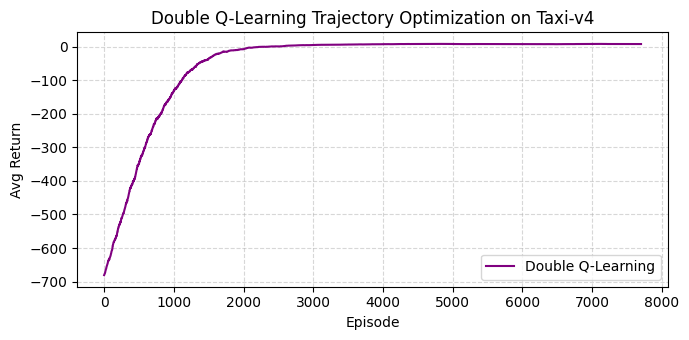

In [6]:
def double_q_learning(env, n_episodes=10_000, alpha=0.1, gamma=0.99, eps_start=1.0, eps_end=0.01, eps_decay=0.999):
    Q1 = np.zeros((n_s, n_a))
    Q2 = np.zeros((n_s, n_a))
    eps = eps_start
    returns_per_ep = []

    for ep in range(n_episodes):
        s, _ = env.reset()
        ep_return = 0.0
        done = False

        while not done:
            if np.random.rand() < eps:
                a = env.action_space.sample()
            else:
                a = np.argmax(Q1[s] + Q2[s])

            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc

            if np.random.rand() < 0.5:
                best_a = np.argmax(Q1[ns])
                Q1[s, a] += alpha * (r + gamma * Q2[ns, best_a] * (not done) - Q1[s, a])
            else:
                best_a = np.argmax(Q2[ns])
                Q2[s, a] += alpha * (r + gamma * Q1[ns, best_a] * (not done) - Q2[s, a])

            s = ns
            ep_return += r

        eps = max(eps_end, eps * eps_decay)
        returns_per_ep.append(ep_return)

    return Q1, Q2, returns_per_ep

print("--- EXERCISE 3 RUNNING ---")
Q1_d, Q2_d, double_q_returns = double_q_learning(env, n_episodes=8000)

window = 300
rolling_double_q = np.convolve(double_q_returns, np.ones(window)/window, mode='valid')

plt.figure(figsize=(7, 3.5))
plt.plot(rolling_double_q, color='purple', linewidth=1.5, label='Double Q-Learning')
plt.xlabel('Episode')
plt.ylabel('Avg Return')
plt.title('Double Q-Learning Trajectory Optimization on Taxi-v4')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
